<a href="https://colab.research.google.com/github/nurqalbuam-design/Praktikum-Analisis-Deret-Waktu/blob/main/Tugas_Kelompok_9_Minggu_4_STA1542_Eksplorasi_Data_Deret_Waktu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EKSPLORASI DATA DERET WAKTU
### Praktikum STA1542 — Minggu 4
**Kelompok 9**


1.   Nurqalbu Abd.Mutalip (M0501251021)
2.   Fatiya Hanifah (M0501251053)
3.   Muhammad Alief Nur Widiyanto (M0501261096)


## 1. Persiapan Library
Bagian ini memuat instalasi dan pemanggilan library yang digunakan untuk membaca data, membuat visualisasi, menghitung ACF–PACF, melakukan dekomposisi, uji ADF, serta transformasi Box–Cox.


In [ ]:
#Install terlebih dahulu package PythonTsa
!pip install PythonTsa

# menginstall package pydataset
!pip install pydataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939458 sha256=f61576f39224420f5b36697218dd0d1d5b9ed61f6914b44fb68adc9e9094969d
  Stored in directory: /root/.cache/pip/wheels/49/2a/45/180e1199b8d925b5c43df8f9850dcc2e5dfc94e3e99a55b83e
Successfully built pydataset


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from PythonTsa.plot_acf_pacf import acf_pacf_fig
from pydataset import data
from statsmodels.datasets import get_rdataset

import warnings
warnings.filterwarnings("ignore")

initiated datasets repo at: /root/.pydataset/


## 2. Input dan Pemeriksaan Awal Data
Data produksi teh dibaca dari file Excel. Pemeriksaan awal dilakukan untuk melihat beberapa baris pertama, tipe data setiap variabel, dan keberadaan *missing value*.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving produksi teh nasional.xlsx to produksi teh nasional.xlsx


In [ ]:
import pandas as pd

teh = pd.read_excel('produksi teh nasional.xlsx')
teh.head()

,waktu,teh
0,Januari,8.8
1,Februari,7.9
2,Maret,8.5
3,April,9.3
4,Mei,10.3


In [ ]:
teh=pd.read_excel('/content/produksi teh nasional.xlsx')

teh.head()

,waktu,teh
0,Januari,8.8
1,Februari,7.9
2,Maret,8.5
3,April,9.3
4,Mei,10.3


In [ ]:
#melihat struktur data
teh.dtypes

,0
waktu,object
teh,float64


In [ ]:
#cek missing values
teh.isnull().sum()

,0
waktu,0
teh,0


## 3. Pembentukan Indeks Waktu
Data merupakan data bulanan yang dimulai pada Januari 2009. Oleh karena itu, dibuat indeks waktu bulanan dengan frekuensi awal bulan (`MS`), kemudian kolom `date` dijadikan indeks deret waktu.


In [ ]:
teh['date'] = pd.date_range(
    start='2009-01-01',
    periods=len(teh),
    freq='MS'
)

In [ ]:
teh.head()

,waktu,teh,date
0,Januari,8.8,2009-01-01
1,Februari,7.9,2009-02-01
2,Maret,8.5,2009-03-01
3,April,9.3,2009-04-01
4,Mei,10.3,2009-05-01


In [ ]:
teh.dtypes

,0
waktu,object
teh,float64
date,datetime64[ns]


In [ ]:
teh = teh.set_index('date')

In [ ]:
teh.head()

,waktu,teh
date,,
2009-01-01,Januari,8.8
2009-02-01,Februari,7.9
2009-03-01,Maret,8.5
2009-04-01,April,9.3
2009-05-01,Mei,10.3


## 4. Eksplorasi Visual Deret Waktu
Plot deret waktu digunakan untuk melihat pola umum data, seperti kecenderungan (*trend*), musiman, perubahan ragam, dan kemungkinan pencilan.


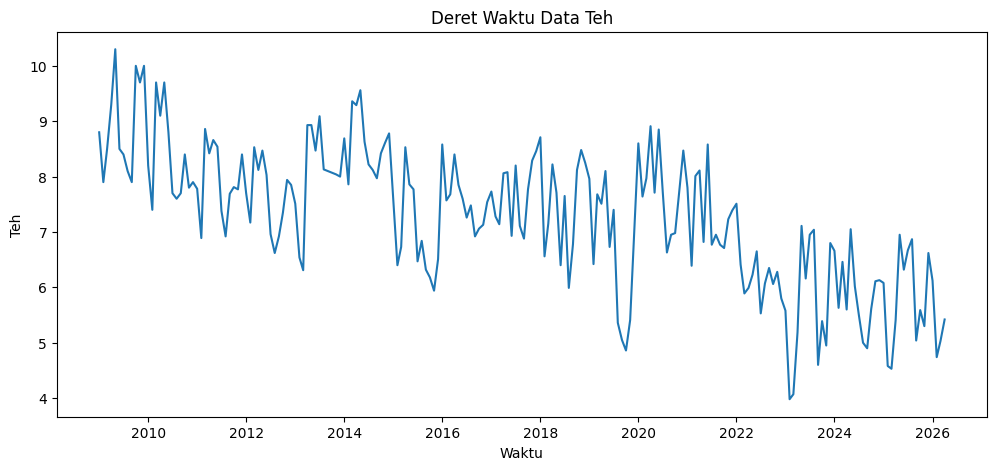

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(teh.index, teh['teh'])

plt.title('Deret Waktu Data Teh')
plt.xlabel('Waktu')
plt.ylabel('Teh')

plt.show()

### Interpretasi Plot Deret
Secara visual, data teh menunjukkan **kecenderungan menurun dalam jangka panjang** dari awal hingga akhir periode pengamatan. Di sekitar kecenderungan tersebut terdapat fluktuasi bulanan yang cukup jelas. Pola ini menunjukkan bahwa nilai tengah deret tidak tampak konstan sepanjang waktu, sehingga terdapat indikasi awal bahwa deret belum stasioner dalam nilai tengah.


## 5. Pemeriksaan ACF dan PACF Data Asli
Plot ACF dan PACF digunakan untuk melihat pola ketergantungan antarwaktu. Dalam tahap eksplorasi kestasioneran, perhatian utama diberikan pada pola ACF, sedangkan PACF lebih banyak membantu mengidentifikasi struktur autoregresif pada tahap pemodelan.


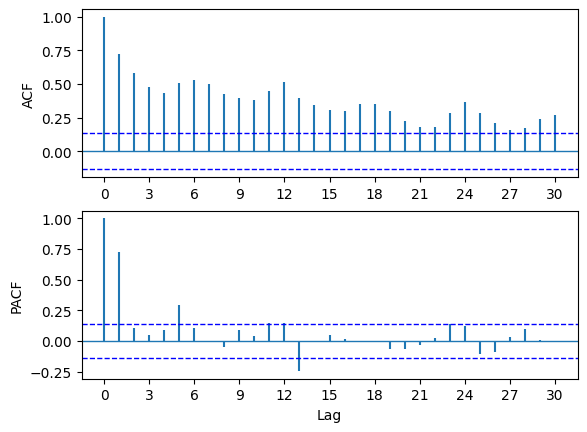

In [ ]:
# Membuat plot ACF dan PACF data teh
acf_pacf_fig(
    teh['teh'],
    both=True,
    lag=30
)

### Interpretasi ACF dan PACF
Plot ACF menunjukkan autokorelasi yang cukup tinggi pada lag-lag awal dan **meluruh secara perlahan (*slow decay*)**. Banyak lag masih berada di luar batas kepercayaan. Pola ini menunjukkan bahwa pengaruh pengamatan masa lalu bertahan cukup lama dan mendukung dugaan bahwa deret belum stasioner dalam nilai tengah.

Plot PACF menunjukkan autokorelasi parsial yang kuat terutama pada lag awal, tetapi pada tahap ini PACF tidak digunakan sebagai satu-satunya dasar untuk menyimpulkan kestasioneran.

Temuan dari ACF konsisten dengan plot deret waktu yang sebelumnya memperlihatkan kecenderungan menurun.


## 6. Uji Kestasioneran dalam Nilai Tengah: Augmented Dickey-Fuller (ADF)

Hipotesis uji ADF:

$H_0$: deret memiliki unit root / tidak stasioner

$H_1$: deret tidak memiliki unit root / stasioner

Dengan taraf nyata 5%:
- Jika *p-value* < 0.05, maka $H_0$ ditolak.
- Jika *p-value* ≥ 0.05, maka gagal menolak $H_0$.


In [ ]:
# Uji unit-root Augmented Dickey Fuller
from statsmodels.tsa.stattools import adfuller

hasil_adf = adfuller(teh['teh'].dropna())

print('ADF Statistic :', hasil_adf[0])
print('p-value       :', hasil_adf[1])

ADF Statistic : -1.554268995848352
p-value       : 0.5065150881326727


### Interpretasi Uji ADF Data Asli
Diperoleh **ADF Statistic = -1.5543** dan **p-value = 0.5065**. Karena *p-value* lebih besar dari 0.05, maka **gagal menolak $H_0$**. Dengan demikian, belum terdapat cukup bukti bahwa data teh stasioner dalam nilai tengah.

Hasil ini konsisten dengan plot deret yang menunjukkan kecenderungan menurun dan plot ACF yang memperlihatkan pola *slow decay*. Selanjutnya, struktur deret dieksplorasi melalui dekomposisi dan kestabilan ragam diperiksa secara terpisah dengan Box–Cox.


## 7. Dekomposisi Deret Waktu
Karena data bersifat bulanan, dekomposisi dilakukan dengan periode 12. Model aditif digunakan untuk memisahkan deret menjadi komponen **trend**, **seasonal**, dan **residual**.


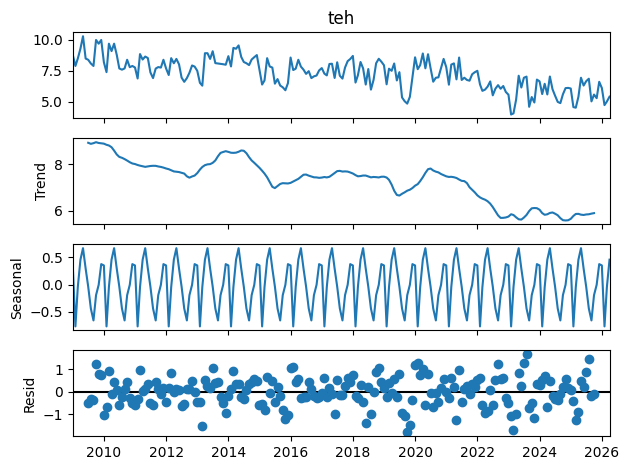

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

result_teh = seasonal_decompose(
    teh['teh'],
    model='additive',
    period=12
)

result_teh.plot()
plt.show()

### Interpretasi Hasil Dekomposisi
Hasil dekomposisi menunjukkan beberapa karakteristik penting:

1. **Trend**  
   Komponen trend secara umum menunjukkan kecenderungan menurun dalam jangka panjang. Meskipun terdapat beberapa kenaikan sementara, level trend pada akhir periode lebih rendah dibandingkan awal periode. Hal ini menunjukkan bahwa nilai tengah deret berubah sepanjang waktu.

2. **Seasonal**  
   Komponen seasonal memperlihatkan pola yang berulang secara teratur setiap 12 bulan. Hal ini menunjukkan adanya pola musiman tahunan pada data teh. Besarnya komponen musiman relatif lebih kecil dibandingkan perubahan pada komponen trend.

3. **Residual**  
   Komponen residual berfluktuasi di sekitar nol dan tidak memperlihatkan trend yang jelas. Beberapa nilai residual relatif besar, tetapi secara umum sisa variasi tersebar di sekitar nol setelah komponen trend dan musiman dipisahkan.

### Keterkaitan dengan ACF dan Uji ADF
Hasil dekomposisi konsisten dengan hasil eksplorasi sebelumnya. Komponen trend menurun menjelaskan mengapa plot ACF data asli menunjukkan *slow decay* dan mengapa uji ADF gagal menolak $H_0$. Dengan demikian, plot deret, ACF, dekomposisi, dan uji ADF secara bersama-sama menunjukkan bahwa data teh **belum stasioner dalam nilai tengah**.


## 8. Pemeriksaan Kestasioneran dalam Ragam dengan Box–Cox
Transformasi Box–Cox digunakan untuk mengevaluasi apakah transformasi skala diperlukan agar ragam lebih stabil. Box–Cox mensyaratkan seluruh nilai data bernilai positif, sehingga nilai minimum data diperiksa terlebih dahulu.


In [ ]:
# Cek apakah semua nilai positif
teh['teh'].min()

3.98

In [ ]:
from scipy.stats import boxcox, boxcox_llf

data_boxcox, lambda_fit, ci = boxcox(
    teh['teh'],
    alpha=0.05
)

print('Nilai lambda:', lambda_fit)
print('Interval kepercayaan lambda:', ci)

Nilai lambda: 1.5393511207219293
Interval kepercayaan lambda: (0.8665738367675977, 2.2284983099273425)


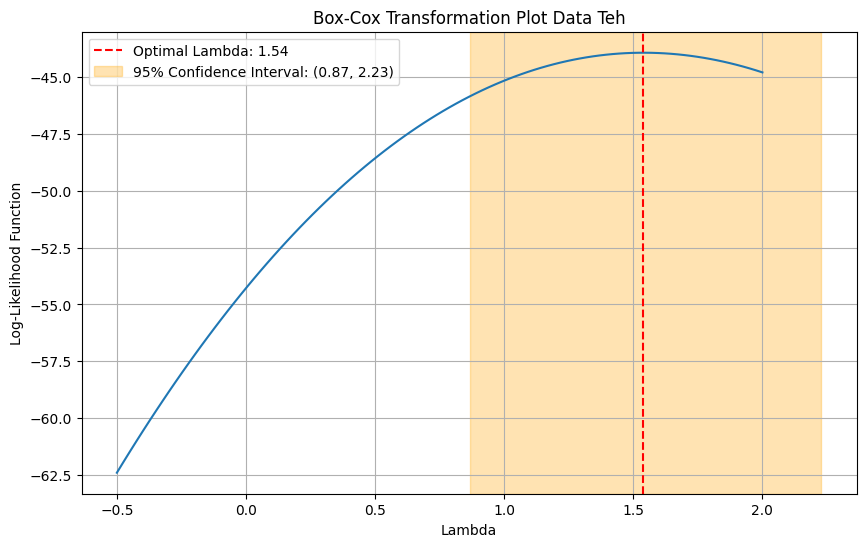

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Membuat rentang nilai lambda
lambdas = np.linspace(-0.5, 2, 100)

# Menghitung log-likelihood untuk masing-masing lambda
llf = [
    boxcox_llf(l, teh['teh'])
    for l in lambdas
]

plt.figure(figsize=(10, 6))

plt.plot(lambdas, llf)

plt.axvline(
    lambda_fit,
    color='r',
    linestyle='--',
    label=f'Optimal Lambda: {lambda_fit:.2f}'
)

plt.axvspan(
    ci[0],
    ci[1],
    color='orange',
    alpha=0.3,
    label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})'
)

plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot Data Teh')

plt.legend()
plt.grid(True)
plt.show()

### Interpretasi Box–Cox
Nilai minimum data teh adalah **3,98**, sehingga seluruh pengamatan bernilai positif dan memenuhi syarat untuk analisis Box–Cox.

Diperoleh:

$
\hat{\lambda}=1{.}5394
$

dengan interval kepercayaan 95%:

$
(0{.}8666,\ 2{.}2285)
$

Karena **$\lambda=1$** berada di dalam interval kepercayaan tersebut, transformasi Box–Cox tidak diperlukan. Dengan demikian, ragam data teh dapat dianggap **cukup stabil pada skala aslinya**.

Jadi, masalah utama pada data lebih berkaitan dengan **ketidakstasioneran dalam nilai tengah**, bukan ketidakstabilan ragam.


## 9. Differencing Orde Pertama
Karena data belum stasioner dalam nilai tengah dan ragamnya telah dianggap cukup stabil, dilakukan differencing orde pertama untuk menghilangkan kecenderungan jangka panjang.


In [ ]:
# Differencing orde pertama
teh['teh_diff'] = teh['teh'].diff()

# Menghilangkan nilai NA akibat differencing
teh_diff = teh['teh_diff'].dropna()

teh_diff.head()

,teh_diff
date,
2009-02-01,-0.9
2009-03-01,0.6
2009-04-01,0.8
2009-05-01,1.0
2009-06-01,-1.8


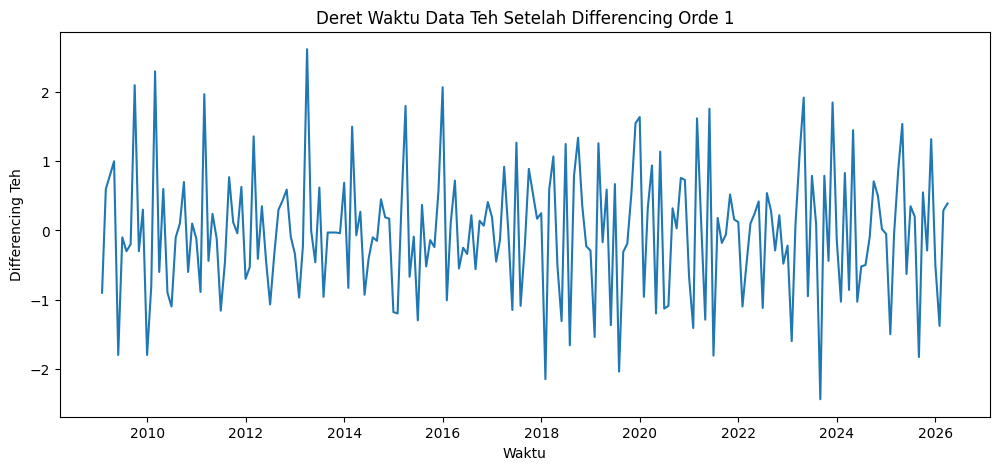

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(teh_diff)

plt.title('Deret Waktu Data Teh Setelah Differencing Orde 1')
plt.xlabel('Waktu')
plt.ylabel('Differencing Teh')

plt.show()

### Interpretasi Plot Setelah Differencing
Setelah differencing orde pertama, deret tampak berfluktuasi di sekitar nol dan tidak lagi menunjukkan kecenderungan naik atau turun yang jelas. Secara visual, pola ini menunjukkan bahwa perubahan nilai tengah yang terdapat pada data asli telah banyak berkurang.


## 10. Evaluasi Setelah Differencing
Kestasioneran setelah differencing diperiksa kembali melalui plot ACF–PACF dan uji ADF.


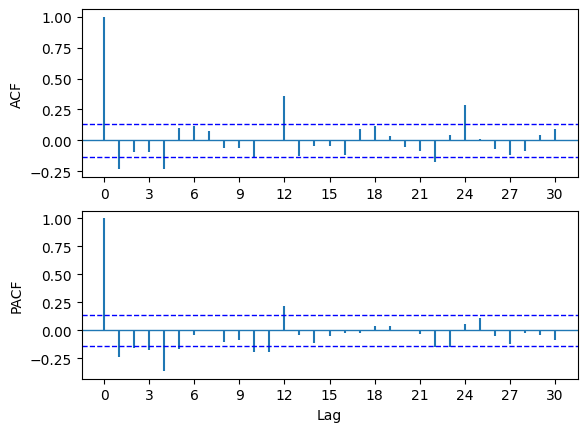

In [ ]:
acf_pacf_fig(
    teh_diff,
    both=True,
    lag=30
)

### Interpretasi ACF dan PACF Setelah Differencing
Plot ACF setelah differencing tidak lagi menunjukkan pola *slow decay* seperti pada data asli. Sebagian besar nilai autokorelasi berada di sekitar nol dan dalam batas kepercayaan, sehingga hasil ini mendukung bahwa differencing telah mengurangi ketidakstasioneran dalam nilai tengah.

Namun, masih terlihat autokorelasi yang menonjol pada **lag 12 dan 24**. Karena data bersifat bulanan, pola tersebut mengindikasikan bahwa struktur musiman tahunan masih tersisa. Temuan ini konsisten dengan komponen seasonal pada hasil dekomposisi.

Pada tahap ini, pola musiman tersebut cukup **diidentifikasi sebagai karakteristik deret** dan tidak perlu langsung ditangani dengan seasonal differencing karena fokus analisis masih berada pada tahap eksplorasi.


In [ ]:
from statsmodels.tsa.stattools import adfuller

hasil_adf_diff = adfuller(teh_diff)

print('ADF Statistic :', hasil_adf_diff[0])
print('p-value       :', hasil_adf_diff[1])

ADF Statistic : -5.374835748356827
p-value       : 3.82476060404631e-06


### Interpretasi Uji ADF Setelah Differencing
Setelah differencing orde pertama diperoleh **ADF Statistic = -5.3748** dan **p-value = 3.8248 × 10⁻⁶**. Karena *p-value* lebih kecil dari 0.05, maka $H_0$ ditolak.

Dengan demikian, setelah differencing orde pertama, data teh **telah stasioner dalam nilai tengah**. Hasil ini konsisten dengan plot deret setelah differencing yang berfluktuasi di sekitar nol serta plot ACF yang tidak lagi menunjukkan pola *slow decay*.


## 11. Kesimpulan Eksplorasi
Berdasarkan seluruh tahapan eksplorasi, dapat disimpulkan bahwa:

1. Data teh menunjukkan **trend menurun** dalam jangka panjang.
2. Plot ACF data asli menunjukkan pola *slow decay*, yang mengindikasikan ketidakstasioneran dalam nilai tengah.
3. Uji ADF data asli menghasilkan *p-value* 0.5065, sehingga gagal menolak $H_0$ dan menunjukkan bahwa data belum stasioner dalam nilai tengah.
4. Dekomposisi menunjukkan adanya **trend menurun** dan **pola musiman tahunan**.
5. Hasil Box–Cox memberikan $\hat{\lambda}=1,5394$ dengan interval kepercayaan 95% $(0.8666,\ 2.2285)$. Karena nilai 1 berada dalam interval tersebut, transformasi Box–Cox tidak diperlukan dan ragam dianggap cukup stabil.
6. Setelah differencing orde pertama, uji ADF menghasilkan *p-value* $3.8248 × 10⁻⁶$, sehingga deret telah stasioner dalam nilai tengah.
7. ACF setelah differencing masih memperlihatkan pola pada lag 12 dan 24, yang mengindikasikan adanya struktur musiman tahunan. Karena pada bagian ini masih berfokus pada eksplorasi, pola tersebut cukup dicatat sebagai karakteristik data dan belum perlu ditangani lebih lanjut.

Secara keseluruhan, **differencing orde pertama sudah cukup untuk mengatasi ketidakstasioneran dalam nilai tengah**, sedangkan struktur musiman tahunan tetap menjadi karakteristik penting yang perlu diperhatikan pada tahap pemodelan selanjutnya.